<a href="https://colab.research.google.com/github/MaggieHDez/ClassFiles/blob/PLN/agrupamientoDeTexto.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
!pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 63.7 MB/s eta 0:00:00


In [4]:
import pandas as pd
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
from sklearn.datasets import fetch_20newsgroups
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from sklearn.decomposition import PCA
from gensim.models import Word2Vec
import numpy as np
import matplotlib.pyplot as plt
from wordcloud import WordCloud

nltk.download('stopwords', quiet = True)
nltk.download('wordnet', quiet = True)
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)

stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

# --- Cargar dataset ---
dataset = fetch_20newsgroups(subset='all', remove=('headers','footers','quotes'))
docs_raw = dataset.data
df = pd.DataFrame({'text': docs_raw}) # Convierte docs_raw a dataFrame

# --- Preprocesamiento ---
def preprocesamiento(texto):
  texto = texto.lower() # Convertir a minúsculas
  texto = re.sub(r'<.*?>', '', texto)  # quitar HTML
  texto = re.sub(r'https?://\S+|www\.\S+', '', texto) # Eliminar URL
  texto = re.sub(r'[\w\._%+-]+@[\w.-]+\.[A-Za-z]{2,}', '', texto) # Eliminar email
  texto = re.sub(r'(?<!\w)@\w+', '', texto) # Eliminar menciones
  texto = re.sub(r'(?<!\w)#(\w+)', r'\1', texto)  # Reemplaza #hashtag por hashtag
  texto = re.sub(r'[^\w\s]', '', texto) # Eliminar puntuación
  texto = re.sub(r'\d+', '', texto)  # elimina números
  texto = re.sub(r'([aieou])\1+', r'\1', texto) # Eliminar vocales repetidas
  texto = re.sub(r'([bcdfghjklmnpqrstvwxyz])\1{2,}', r'\1', texto) # Eliminar consonantes repetidas
  texto = re.sub(r'\s+', ' ', texto).strip() # Eliminar espacios
  # tokenizar
  tokens = word_tokenize(texto)
  # quitar stopwords y lematizar
  tokens = [lemmatizer.lemmatize(word) for word in tokens if word not in stop_words]
  return tokens

# --- Preprocesar textos ---
df['tokens'] = df['text'].astype(str).apply(preprocesamiento)
df = df[df['tokens'].map(len) > 5].reset_index(drop=True) # Por si hay ruido
print(f"Total de documentos: {len(df)}")
print(df.head())

# --- Entrenamiento de Embeddings ---
def entrenamiento_word2vec(df):
    print("\nEntrenando modelo Word2Vec...")
    model_w2v = Word2Vec(
        sentences=df['tokens'],
        vector_size=100,
        window=8,
        min_count=2,
        workers=5,
        epochs=50,
        seed=42
    )

    # Generar embedding promedio por documento
    X = np.array([
        np.mean([model_w2v.wv[word] for word in tokens if word in model_w2v.wv]
                or [np.zeros(100)], axis=0)
        for tokens in df['tokens']
    ])

    print(f"Embeddings generados con Word2Vec: {X.shape}")
    return X


# --- Clustering con K-Means ---
def evaluar_kmeans(X, K_range, verbose=True):
  print(f"\nEjecutando K-Means con K={K_range}")
  wcss, sil_scores, db_scores, ch_scores = [], [], [], []

  for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X)
    wcss.append(kmeans.inertia_)
    score = silhouette_score(X, labels)
    sil_scores.append(score)
    db = davies_bouldin_score(X, labels)
    db_scores.append(db)
    ch = calinski_harabasz_score(X, labels)
    ch_scores.append(ch)
    if verbose:
      print(f"K={k}: Silhouette={score:.3f}, Inercia={kmeans.inertia_:.2f}, "f"Davies-Bouldin={db:.3f}, Calinski-Harabasz={ch:.2f}")
  return wcss, sil_scores, db_scores, ch_scores, labels, kmeans

def graficar_metricas(K_range, wcss, sil_scores, db_scores, ch_scores):
  # Gráfica Método del Codo
  plt.figure(figsize=(7,5))
  plt.plot(K_range, wcss, 'bo-')
  plt.xlabel('Número de Clústeres (K)')
  plt.ylabel('Suma de cuadrados (WCSS)')
  plt.title('Método del Codo')
  plt.show()

  # Gráfica Coeficiente Silhouette
  plt.figure(figsize=(7,5))
  plt.plot(K_range, sil_scores, marker='o')
  plt.xlabel('Número de Clústeres (K)')
  plt.ylabel('Coeficiente Silhouette')
  plt.title('Silhouette Promedio por K')
  plt.show()

  # Gráfica Davies Bouldin
  plt.figure(figsize=(7,5))
  plt.plot(K_range, db_scores, marker='o')
  plt.xlabel('Número de Clústeres (K)')
  plt.ylabel('Davies Bouldin Score')
  plt.title('Davies Bouldin Score por K')
  plt.show()

  # Calinski-Harabasz
  plt.figure(figsize=(7,5))
  plt.plot(K_range, ch_scores, marker='o')
  plt.xlabel('Número de Clústeres (K)')
  plt.ylabel('Calinski-Harabasz Score')
  plt.title('Calinski-Harabasz Score por K')
  plt.show()



# --- Visualizaciones PCA + WordCloud ---
def visualizar_resultados(X, df, labels, k_opt):
  print(f"\nGenerando visualizaciones PCA y nubes de palabras (K={k_opt})...")
  # PCA 2D
  pca = PCA(n_components=2, random_state=42)
  X_pca = pca.fit_transform(X)
  plt.figure(figsize=(8,6))
  plt.scatter(X_pca[:,0], X_pca[:,1], c=labels, cmap='Set2', s=10)
  plt.title(f'Clusters K-Means (PCA 2D, K={k_opt})')
  plt.xlabel('K-Means - Componente principal 1')
  plt.ylabel('K-Means - Componente principal 2')
  plt.show()

  # Nubes de palabras por clúster
  for i in range(k_opt):
      text_cluster = ' '.join([' '.join(df['tokens'][j]) for j in range(len(df)) if labels[j] == i])
      if len(text_cluster.strip()) == 0: continue
      wc = WordCloud(width=800, height=400, background_color='white').generate(text_cluster)
      plt.figure(figsize=(8,4))
      plt.imshow(wc, interpolation='bilinear')
      plt.axis('off')
      plt.title(f'Nube de palabras - - Modelo K-Means - Clúster {i}')
      plt.show()

# --- Calcular el mejor eps para dbscan ---
def mejor_eps_dbscan(X, min_samples=5, rango=np.arange(0.5, 3.1, 0.5)):
    resultados = []
    for eps in rango:
        dbscan = DBSCAN(eps=eps, min_samples=min_samples, n_jobs=-1)
        labels = dbscan.fit_predict(X)
        if len(set(labels)) > 1:
            try:
                sil = silhouette_score(X, labels)
                resultados.append((eps, sil))
            except:
                pass
    if not resultados:
        print("No se encontraron clústeres válidos.")
        return None
    mejor_eps = max(resultados, key=lambda x: x[1])[0]
    print(f"Mejor eps sugerido: {mejor_eps}")
    return mejor_eps

# --- Clustering con DBSCAN ---
def evaluar_dbscan(X, eps_values, min_samples_values):
  print("\nEvaluando DBSCAN con distintos parámetros...")
  resultados = []
  for eps in eps_values:
    for ms in min_samples_values:
      dbscan = DBSCAN(eps=eps, min_samples=ms, n_jobs=-1)
      labels = dbscan.fit_predict(X)
      if len(set(labels)) <= 1: continue
      try:
        sil = silhouette_score(X, labels)
        db = davies_bouldin_score(X, labels)
        ch = calinski_harabasz_score(X, labels)
        resultados.append({
          "eps": eps,
          "min_samples": ms,
          "clusters": len(set(labels)) - (1 if -1 in labels else 0),
          "Silhouette": sil,
          "Davies–Bouldin": db,
          "Calinski–Harabasz": ch
        })
        print(f"eps={eps}, min_samples={ms}, clusters={len(set(labels))-1}, "
          f"Silhouette={sil:.3f}, DB={db:.3f}, CH={ch:.2f}")
      except:
        pass
  if not resultados:
    print("\nNo se generaron clústeres válidos.")
    return pd.DataFrame(columns=["eps", "min_samples", "clusters", "Silhouette", "Davies–Bouldin", "Calinski–Harabasz"])
  resultados_df = pd.DataFrame(resultados)
  print("\nResultados DBSCAN ordenados por Silhouette:")
  print(resultados_df.sort_values(by="Silhouette", ascending=False))
  return resultados_df

# --- Visualización DBSCAN ---
def visualizar_dbscan(X, df, labels):
  pca = PCA(n_components=2, random_state=42)
  X_pca = pca.fit_transform(X)
  plt.figure(figsize=(8,6))
  plt.scatter(X_pca[:,0], X_pca[:,1], c=labels, cmap='Accent', s=10)
  plt.title('Clusters DBSCAN (PCA 2D)')
  plt.xlabel('DBSCAN - Componente 1')
  plt.ylabel('DBSCNA - Componente 2')
  plt.show()

  # Wordcloud por cluster
  for i in set(labels):
    if i == -1:  # Ruido
      continue
    text_cluster = ' '.join([' '.join(df['tokens'][j]) for j in range(len(df)) if labels[j] == i])
    wc = WordCloud(width=800, height=400, background_color='white', colormap='tab10').generate(text_cluster)
    plt.figure(figsize=(8,4))
    plt.imshow(wc, interpolation='bilinear')
    plt.axis('off')
    plt.title(f'Nube de palabras - DBSCAN Clúster {i}')
    plt.show()

def comparar_pca(X, labels_km, label_db):
  pca = PCA(n_components=2, random_state=42)
  X_pca = pca.fit_transform(X)
  fig, axes = plt.subplots(1, 2, figsize=(12,5))
  axes[0].scatter(X_pca[:,0], X_pca[:,1], c=labels_km, cmap='Set2', s=10)
  axes[0].set_title('Clusters K-Means (PCA 2D)')
  axes[1].scatter(X_pca[:,0], X_pca[:,1], c=label_db, cmap='Accent', s=10)
  axes[1].set_title('Clusters DBSCAN (PCA 2D)')
  plt.show()

def graficar_metricas_dbscan(resultados_df):
    if resultados_df.empty:
        print("No hay resultados para graficar.")
        return

    # Crea etiquetas de parámetros para eje X
    etiquetas = [f"ε={row['eps']}, m={row['min_samples']}" for idx, row in resultados_df.iterrows()]

    # Coef. de Silhouette
    plt.figure(figsize=(7,5))
    plt.plot(etiquetas, resultados_df["Silhouette"], marker='o')
    plt.xlabel('Parámetros DBSCAN (ε, min_samples)')
    plt.ylabel('Coeficiente Silhouette')
    plt.title('Silhouette por configuración de DBSCAN')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    # Davies Bouldin
    plt.figure(figsize=(7,5))
    plt.plot(etiquetas, resultados_df["Davies–Bouldin"], marker='o', color='orange')
    plt.xlabel('Parámetros DBSCAN (ε, min_samples)')
    plt.ylabel('Davies–Bouldin Score')
    plt.title('Davies–Bouldin por configuración de DBSCAN')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    # Calinski–Harabasz
    plt.figure(figsize=(7,5))
    plt.plot(etiquetas, resultados_df["Calinski–Harabasz"], marker='o', color='green')
    plt.xlabel('Parámetros DBSCAN (ε, min_samples)')
    plt.ylabel('Calinski–Harabasz Score')
    plt.title('Calinski–Harabasz por configuración de DBSCAN')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


Total de documentos: 17701
                                                text  \
0  \n\nI am sure some bashers of Pens fans are pr...   
1  My brother is in the market for a high-perform...   
2  \n\n\n\n\tFinally you said what you dream abou...   
3  \nThink!\n\nIt's the SCSI card doing the DMA t...   
4  1)    I have an old Jasmine drive which I cann...   

                                              tokens  
0  [sure, bashers, pen, fan, pretty, confused, la...  
1  [brother, market, highperformance, video, card...  
2  [finally, said, dream, mediterranean, new, are...  
3  [think, scsi, card, dma, transfer, disk, scsi,...  
4  [old, jasmine, drive, use, new, system, unders...  



Entrenando modelo Word2Vec...
Embeddings generados con Word2Vec: (17701, 100)

Ejecutando K-Means con K=range(2, 11)
K=2: Silhouette=0.140, Inercia=465264.78, Davies-Bouldin=2.383, Calinski-Harabasz=2744.42
K=3: Silhouette=0.089, Inercia=441623.00, Davies-Bouldin=2.973, Calinski-Harabasz=1919.33
K=4: Silhouette=0.078, Inercia=425870.91, Davies-Bouldin=2.811, Calinski-Harabasz=1544.98
K=5: Silhouette=0.066, Inercia=415795.47, Davies-Bouldin=3.171, Calinski-Harabasz=1293.95
K=6: Silhouette=0.072, Inercia=404025.91, Davies-Bouldin=2.946, Calinski-Harabasz=1168.34
K=7: Silhouette=0.072, Inercia=397084.44, Davies-Bouldin=2.998, Calinski-Harabasz=1042.14
K=8: Silhouette=0.063, Inercia=389218.88, Davies-Bouldin=3.039, Calinski-Harabasz=962.35
K=9: Silhouette=0.062, Inercia=382975.81, Davies-Bouldin=2.983, Calinski-Harabasz=891.78
K=10: Silhouette=0.059, Inercia=377291.09, Davies-Bouldin=2.886, Calinski-Harabasz=834.21


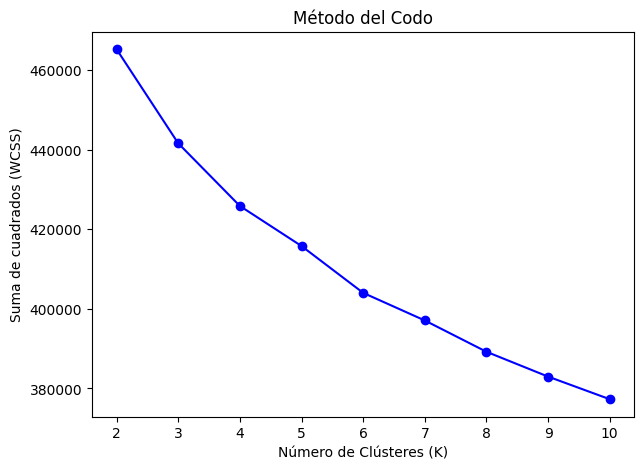

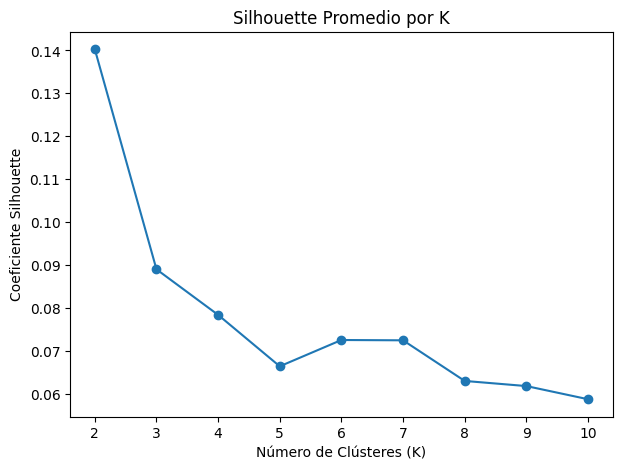

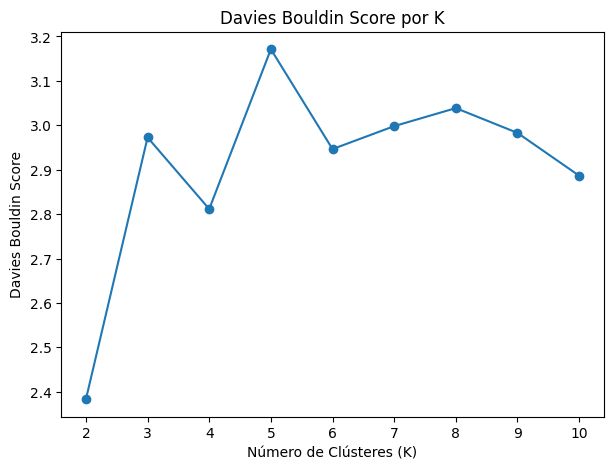

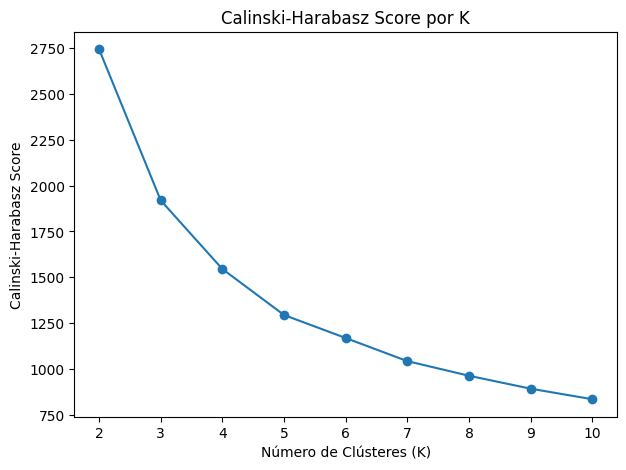

In [6]:
# 1. Entrenar embeddings
X = entrenamiento_word2vec(df)
# 2. Evaluar K-Means y obtener el K óptimo
k_range = range(2,11)
wcss, sil_scores, db_scores, ch_scores, etiquetas, Kmeans = evaluar_kmeans(X, K_range=k_range)
graficar_metricas(k_range, wcss, sil_scores, db_scores, ch_scores)


Ejecutando K-Means con K=[2]

Generando visualizaciones PCA y nubes de palabras (K=2)...


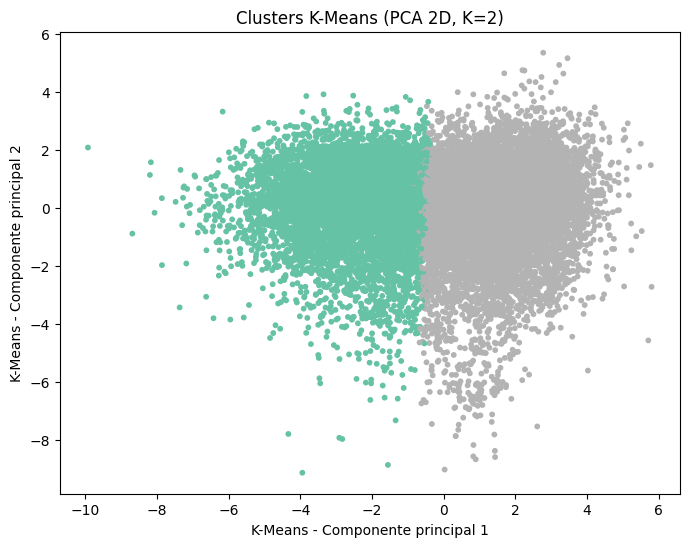

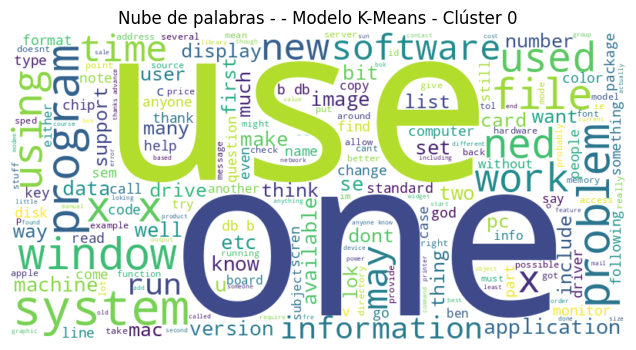

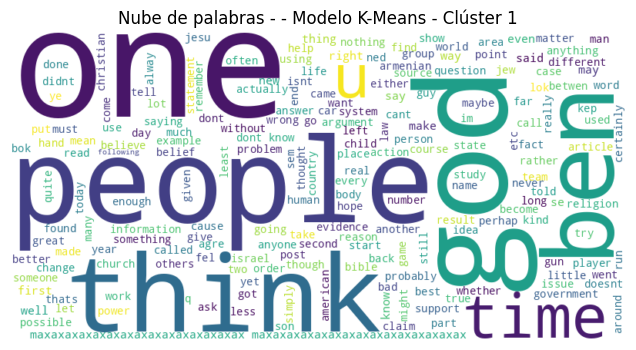


Evaluando DBSCAN con distintos parámetros...
eps=0.3, min_samples=3, clusters=10, Silhouette=-0.153, DB=0.848, CH=8.94
eps=0.5, min_samples=3, clusters=16, Silhouette=-0.165, DB=0.812, CH=8.63
eps=0.5, min_samples=5, clusters=2, Silhouette=0.032, DB=0.874, CH=8.50
eps=0.7, min_samples=3, clusters=18, Silhouette=-0.186, DB=0.840, CH=12.48
eps=0.7, min_samples=5, clusters=3, Silhouette=0.021, DB=0.856, CH=8.90
eps=1.0, min_samples=3, clusters=22, Silhouette=-0.228, DB=0.873, CH=11.78
eps=1.0, min_samples=5, clusters=5, Silhouette=0.015, DB=0.732, CH=26.26

Resultados DBSCAN ordenados por Silhouette:
   eps  min_samples  clusters  Silhouette  Davies–Bouldin  Calinski–Harabasz
2  0.5            5         2    0.031906        0.874427           8.502451
4  0.7            5         3    0.020574        0.855672           8.896758
6  1.0            5         5    0.015475        0.732309          26.258492
0  0.3            3        10   -0.152560        0.847568           8.935190
1  0.5   

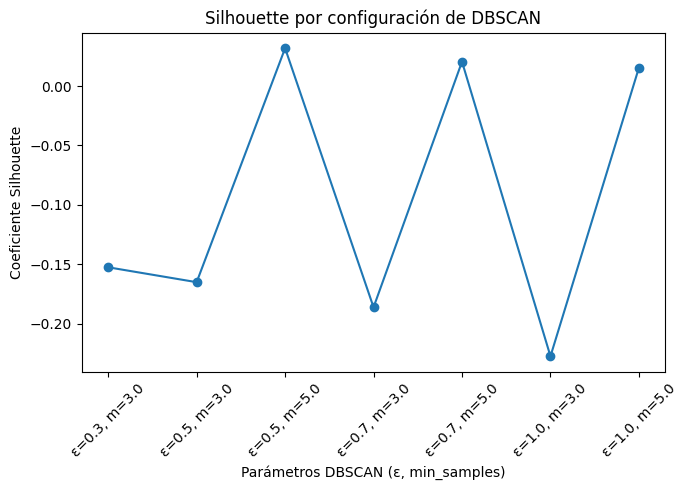

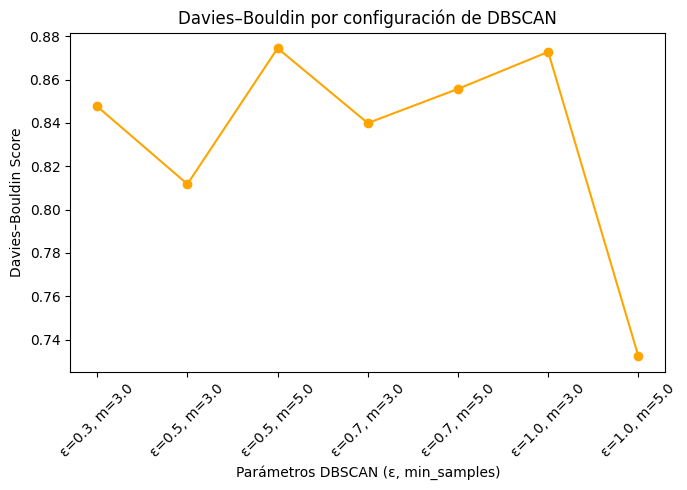

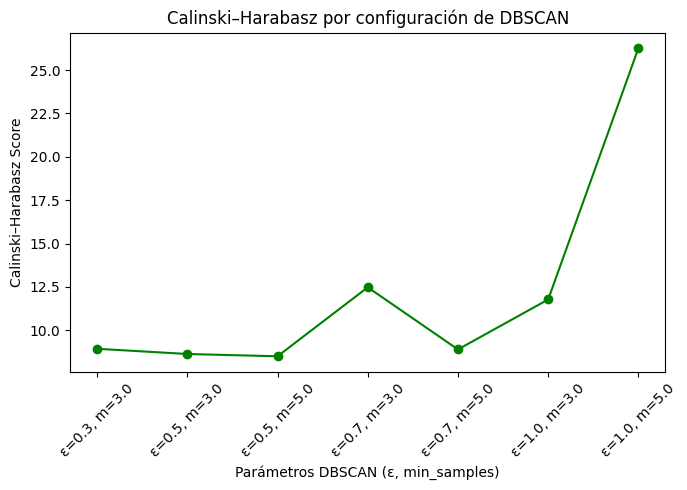

Mejor configuración DBSCAN → eps=0.5, min_samples=5.0
Etiquetas DBSCAN: (array([-1,  0,  1]), array([17690,     6,     5]))


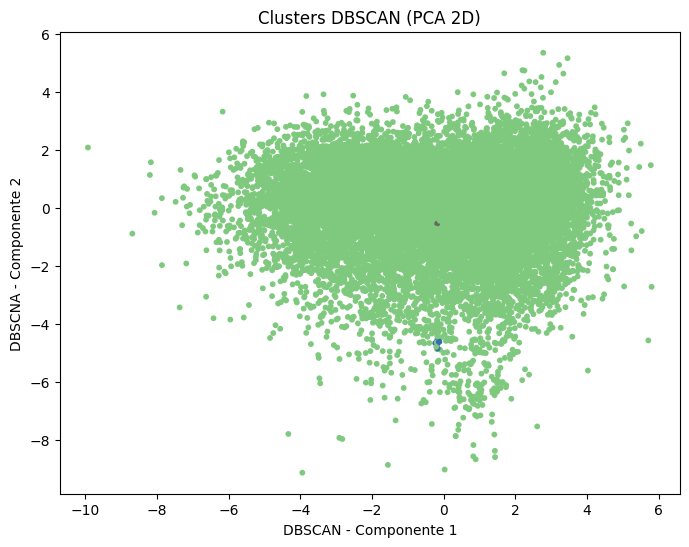

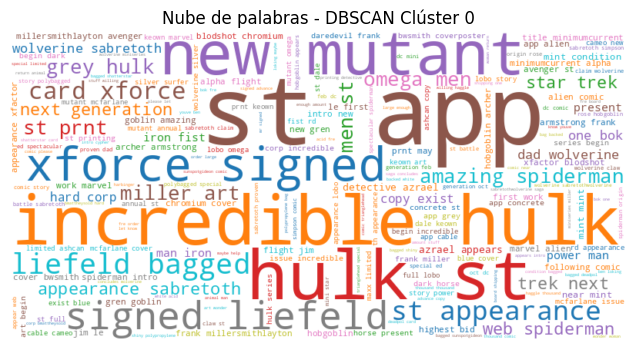

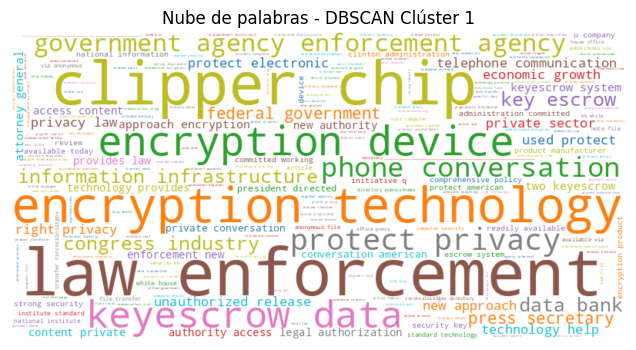

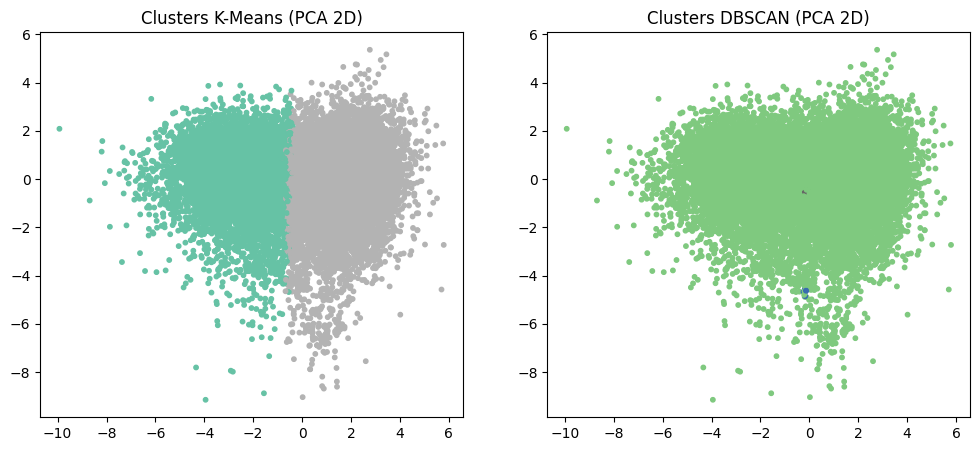


Comparación final de modelos:
 Modelo  Silhouette  Davies-Bouldin  Calinski-Harabasz
K-Means    0.140295        2.383287        2744.422119
 DBSCAN    0.031906        0.874427           8.502451


In [9]:
# --- Entrenar los modelos finales con K óptimo=2 ---
k_opt = 2 # Basado en análisis visual y métricas
_, _, _, _, labels_opt, kmeans_opt = evaluar_kmeans(X, [k_opt], verbose=False)

# --- Visualizar resultados ---
visualizar_resultados(X, df, labels_opt, k_opt)

# --- Evaluar con DBSCAN ---
eps_values = [0.3, 0.5, 0.7, 1.0]
min_samples_values = [3, 5, 10]
resultados_dbscan = evaluar_dbscan(X, eps_values, min_samples_values)
graficar_metricas_dbscan(resultados_dbscan)

# --- Visualizar DBSCAN ---
mejor_fila_dbscan = resultados_dbscan.sort_values(by="Silhouette", ascending=False).iloc[0] # Elegir mejor fila completa

eps_opt = mejor_fila_dbscan["eps"]
min_samples_opt = mejor_fila_dbscan["min_samples"]
labels_db = DBSCAN(eps=eps_opt, min_samples=int(min_samples_opt)).fit_predict(X)

# Imprimir info
print(f"Mejor configuración DBSCAN → eps={eps_opt}, min_samples={min_samples_opt}")
print("Etiquetas DBSCAN:", np.unique(labels_db, return_counts=True))

# Visualización
visualizar_dbscan(X, df, labels_db)
comparar_pca(X, labels_opt, labels_db)

# Comparación final
comaparacion = pd.DataFrame({
    "Modelo": ["K-Means", "DBSCAN"],
    "Silhouette": [
        silhouette_score(X, labels_opt),
        silhouette_score(X, labels_db)
    ],
    "Davies-Bouldin": [
        davies_bouldin_score(X, labels_opt),
        davies_bouldin_score(X, labels_db)
    ],
    "Calinski-Harabasz": [
        calinski_harabasz_score(X, labels_opt),
        calinski_harabasz_score(X, labels_db)
    ]
})

print("\nComparación final de modelos:")
print(comaparacion.to_string(index=False))